**Import Necessary Modules**

In [113]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


**Implement Fast Gradient Signed Method for adversial attack**

In [114]:
def create_advisarial_image_using_FGSM(input_image, input_label, pretrained_model, epsilon=0.1):
    loss_object = tf.keras.losses.CategoricalCrossentropy()
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = pretrained_model(input_image)
        loss = loss_object(input_label, prediction)

    gradient = tape.gradient(loss, input_image)
    signed_grad = tf.sign(gradient)
    adv_image = input_image + signed_grad * epsilon
    # clip adv_image from -1 to 1
    adv_image = tf.clip_by_value(adv_image, -1.0, 1.0)
    return adv_image

In [115]:
def create_advisarial_image_using_Gaussian_Noise(input_image, stddev):

    noise = tf.random.normal(shape=tf.shape(input_image), mean=0.0, stddev=stddev, dtype=input_image.dtype)
    noisy_image = input_image + noise

    noisy_image = tf.clip_by_value(noisy_image, -1, 1)

    return noisy_image

In [116]:
pretrained_model = tf.keras.applications.mobilenet_v2.MobileNetV2(include_top=True,
                                                     weights='imagenet')
pretrained_model.trainable = False

# ImageNet labels
decode_predictions = tf.keras.applications.mobilenet_v2.decode_predictions


In [117]:
def preprocess(image):
  image = tf.cast(image, tf.float32)
  image = tf.image.resize(image, (224, 224))
  image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
  image = image[None, ...]
  return image

def get_imagenet_label(probs):
  return decode_predictions(probs, top=1)[0][0]

In [118]:
image_path = tf.keras.utils.get_file('YellowLabradorLooking_new.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')

input_image = tf.io.read_file(image_path)
input_image = tf.image.decode_image(input_image)

In [119]:
processed_image = preprocess(input_image)
image_probs = pretrained_model.predict(processed_image)



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


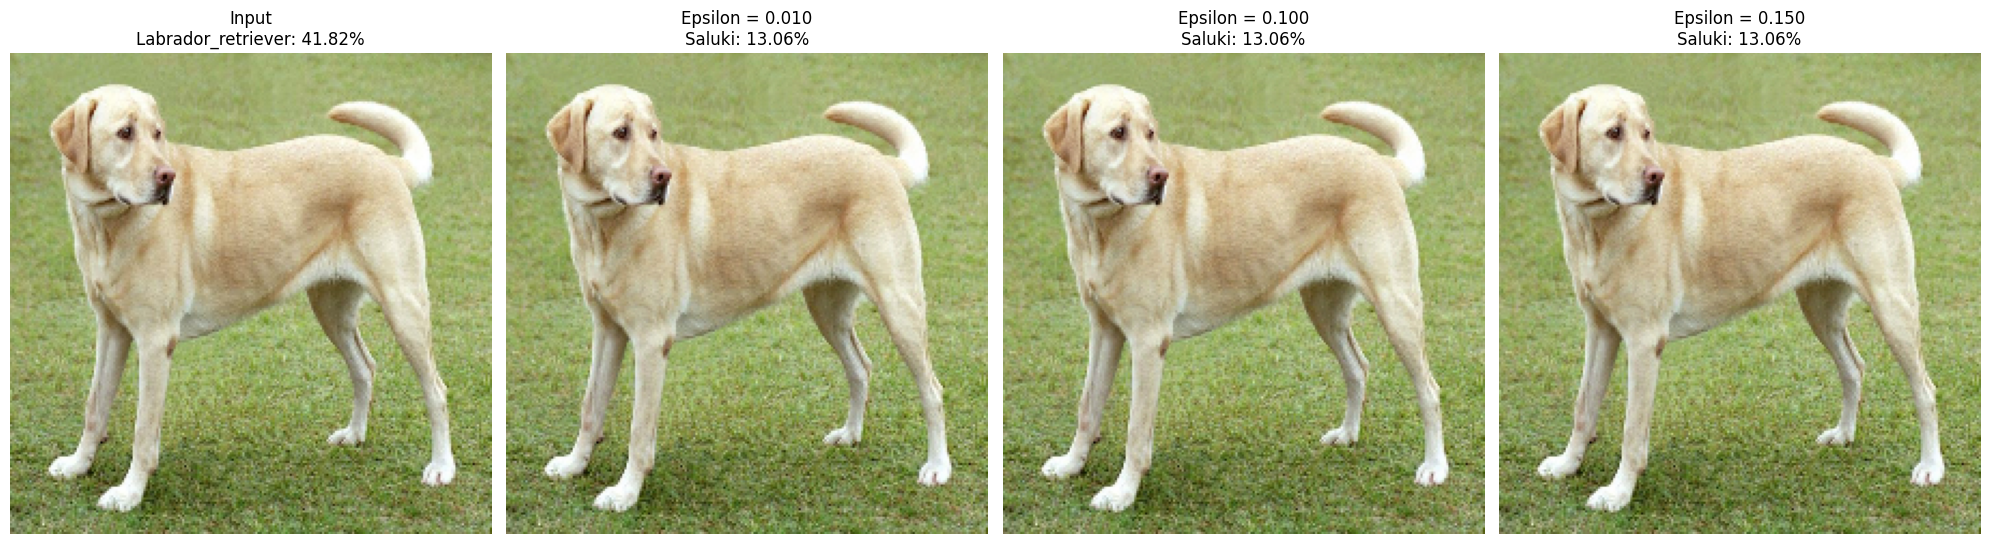

In [136]:
labrador_retriever_index = 208
input_label = tf.one_hot(labrador_retriever_index, depth=1000)
input_label = tf.reshape(input_label, (1, 1000))

epsilons = [0, 0.01, 0.1, 0.15]
descriptions = [('Epsilon = {:0.3f}'.format(eps) if eps else 'Input')
                for eps in epsilons]

plt.figure(figsize=(20, 8))
for i, eps in enumerate(epsilons,1):
    if eps == 0:
        adv_image = processed_image
    else:
        adv_image = create_adversarial_image_using_FSGM(processed_image, input_label, pretrained_model, epsilon=eps)

    probs = pretrained_model.predict(adv_image, verbose=0)
    _, label, confidence = get_imagenet_label(probs)

    vis = adv_image[0].numpy() * 0.5 + 0.5  # [-1,1] -> [0,1]
    vis = np.clip(vis, 0, 1)

    plt.subplot(1, len(epsilons), i)
    plt.imshow(vis); plt.axis('off')
    plt.title(f'{descriptions[i-1]}\n{label}: {confidence*100:.2f}%')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


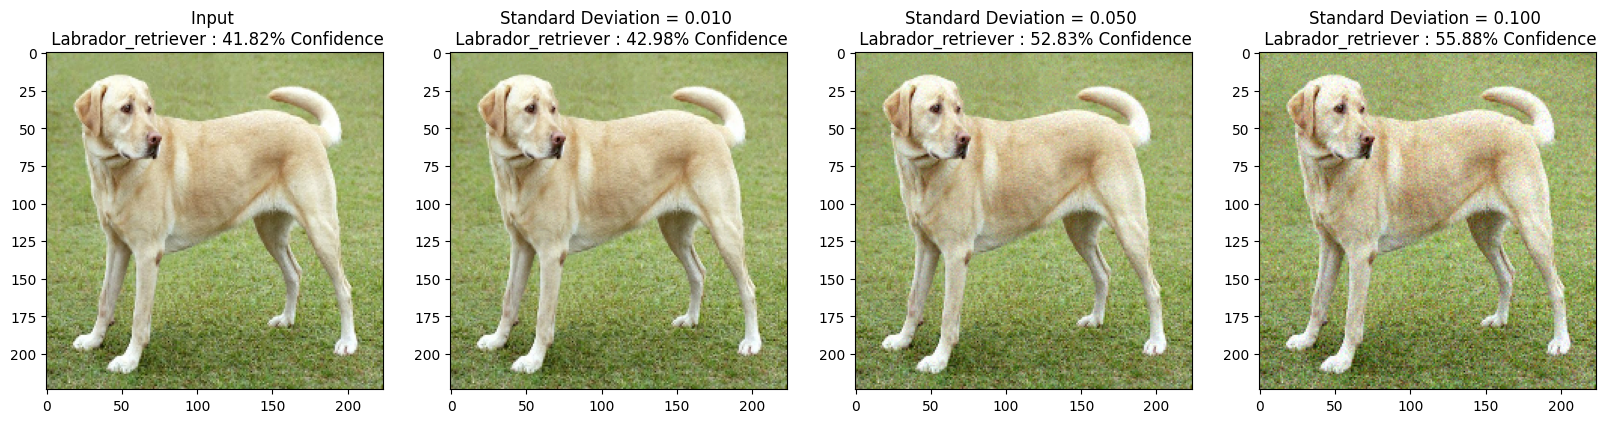

In [126]:
# Using Gaussian Noise
stddevs = [0, 0.01, 0.05, 0.1]
descriptions = [('Standard Deviation = {:0.3f}'.format(std) if std else 'Input')
                for std in stddevs]

plt.figure(figsize=(20, 8))
for std in stddevs:
    # Create adversarial image using Gaussian Noise
    adv_image = create_advisarial_image_using_Gaussian_Noise(processed_image, stddev=std)
    plt.subplot(1, len(stddevs), stddevs.index(std) + 1)
    _, label, confidence = get_imagenet_label(pretrained_model.predict(adv_image))
    plt.imshow(adv_image[0]*0.5+0.5)
    plt.title('{} \n {} : {:.2f}% Confidence'.format(descriptions[stddevs.index(std)],
                                                    label, confidence*100))

plt.show()